In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("preprocessed_kids_screentime.csv")
df.head()


,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Urban_or_Rural,Age_Band,High_Screen_Time
0,14,Male,3.99,Smartphone,True,0.42,Urban,11-15,False
1,11,Female,4.61,Laptop,True,0.30,Urban,11-15,True
2,18,Female,3.73,Tv,True,0.32,Urban,16-18,False
3,15,Female,1.21,Laptop,False,0.39,Urban,11-15,False
4,12,Female,5.89,Smartphone,True,0.49,Urban,11-15,True


In [5]:
df["cohort"] = df["Age_Band"] + " × " + df["Primary_Device"]
df["cohort"].head()


0    11-15 × Smartphone
1        11-15 × Laptop
2            16-18 × Tv
3        11-15 × Laptop
4    11-15 × Smartphone
Name: cohort, dtype: object

In [6]:
top_cohorts = df["cohort"].value_counts().head(10)
print(top_cohorts)


cohort
11-15 × Smartphone    2166
16-18 × Smartphone    1329
6-10 × Smartphone     1073
6-10 × Tv             1045
11-15 × Laptop         922
11-15 × Tv             889
6-10 × Tablet          556
16-18 × Tv             553
16-18 × Laptop         511
11-15 × Tablet         426
Name: count, dtype: int64


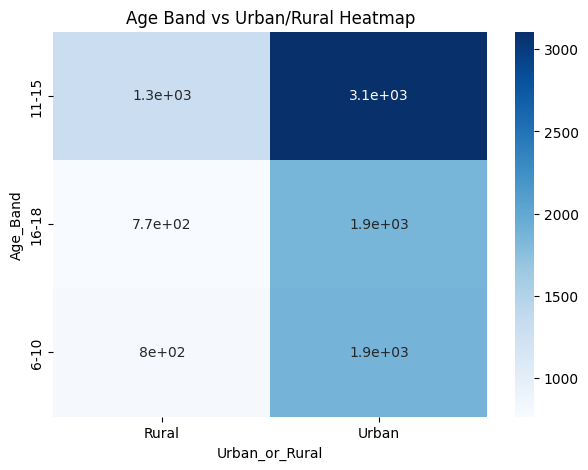

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_data = df.pivot_table(
    index="Age_Band",
    columns="Urban_or_Rural",
    values="Age",
    aggfunc="count",
    fill_value=0
)

plt.figure(figsize=(7,5))
sns.heatmap(heatmap_data, annot=True, cmap="Blues")
plt.title("Age Band vs Urban/Rural Heatmap")
plt.show()


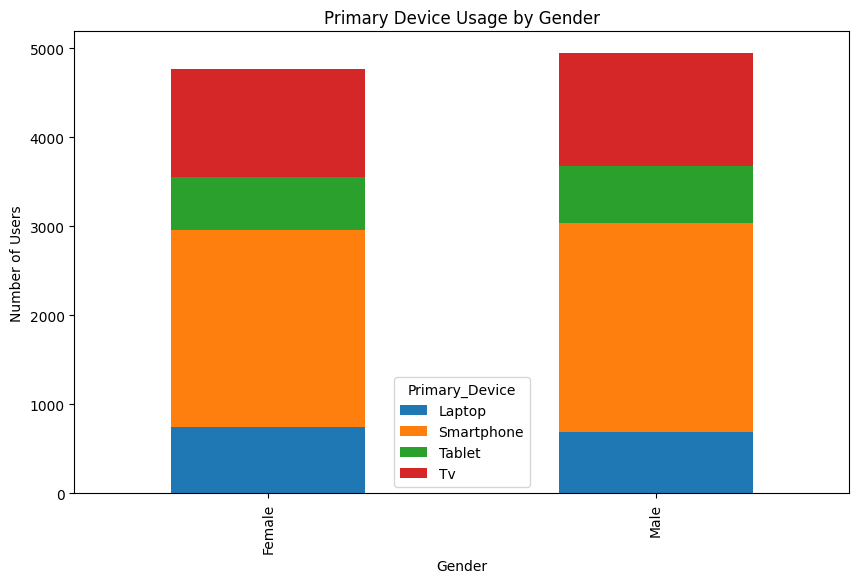

In [8]:
device_gender = df.groupby(["Gender", "Primary_Device"]).size().unstack()

device_gender.plot(kind="bar", stacked=True, figsize=(10,6))
plt.title("Primary Device Usage by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Users")
plt.show()


In [10]:
df["cohort"] = df["Age_Band"].astype(str) + " × " + df["High_Screen_Time"].astype(str)
df["cohort"].head()


0    11-15 × False
1     11-15 × True
2    16-18 × False
3    11-15 × False
4     11-15 × True
Name: cohort, dtype: object

In [11]:
df["cohort"].value_counts()


cohort
11-15 × True     2904
16-18 × True     1770
11-15 × False    1499
6-10 × False     1398
6-10 × True      1276
16-18 × False     865
Name: count, dtype: int64

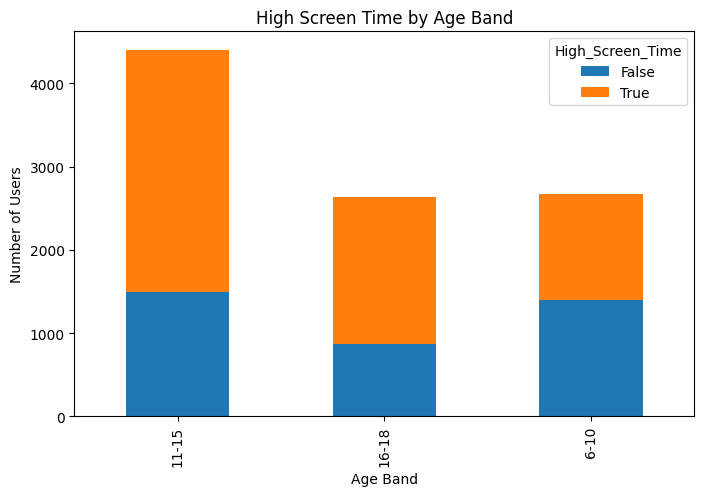

In [12]:
import matplotlib.pyplot as plt

age_high = df.groupby(["Age_Band", "High_Screen_Time"]).size().unstack()

age_high.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("High Screen Time by Age Band")
plt.xlabel("Age Band")
plt.ylabel("Number of Users")
plt.show()
